In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from research_agent.tools import tavily_search, think_tool

tools = [tavily_search, think_tool]

In [3]:
from datetime import datetime

from research_agent.prompts import (
    RESEARCH_WORKFLOW_INSTRUCTIONS,
    RESEARCHER_INSTRUCTIONS,
    SUBAGENT_DELEGATION_INSTRUCTIONS,
)
from utils import format_messages, show_prompt


In [4]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the research tools provided to you to find resources that can help answer the research      │
│  question.                                                                                                      │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Research Tools>                                                                                     │
│  You have access to two specific research tools:                                                                │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Research Tools>                                                                                    │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Complex queries**: Use up to 5 search tool calls maximum                                                   │
│  - **Always stop**: After 5 search tool calls if you cannot find the right sources                              │
│                                                       

` Add traditional tools here in the prompt which will the actual real tools for Deep Agent `

In [5]:
# Get current date
current_date = datetime.now().strftime("%Y-%m-%d")  # noqa: DTZ005

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=current_date),
    "tools": [tavily_search, think_tool],
}

In [6]:
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Combine orchestrator instructions (RESEARCHER_INSTRUCTIONS only for sub-agents)
INSTRUCTIONS = (
    RESEARCH_WORKFLOW_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    +  SUBAGENT_DELEGATION_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
    )
)

show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # Research Workflow                                                                                            │
│                                                                                                                 │
│  Follow this workflow for all research requests:                                                                │
│                                                                                                                 │
│  1. **Plan**: Create a todo list with write_todos to break down the research into focused tasks                 │
│  2. **Save the request**: Use write_file() to save the user's research question to `/research_request.md`       │
│  3. **Research**: Delegate research tasks to sub-agents using the task() tool - ALWAYS use sub-agents for       │
│  research, never conduct research yourself                                                                      │
│  4. **Synthesize**: Review all sub-agent findings and consolidate citations (each unique URL gets one number    │
│  across all findings)                                                                                           │
│  5. **Write Report**: Write a comprehensive final report to `/final_report.md` (see Report Writing Guidelines   │
│  below)                                                                                                         │
│  6. **Verify**: Read `/research_request.md` and confirm you've addressed all aspects with proper citations and  │
│  structure                                                                                                      │
│                                                                                                                 │
│  ## Research Planning Guidelines                                                                                │
│  - Batch similar research tasks into a single TODO to minimize overhead                                         │
│  - For simple fact-finding questions, use 1 sub-agent                                                           │
│  - For comparisons or multi-faceted topics, delegate to multiple parallel sub-agents                            │
│  - Each sub-agent should research one specific aspect and return findings                                       │
│                                                                                                                 │
│  ## Report Writing Guidelines                                                                                   │
│                                                                                                                 │
│  When writing the final report to `/final_report.md`, follow these structure patterns:                          │
│                                                                                                                 │
│  **For comparisons:**                                                                                           │
│  1. Introduction                                                                                                │
│  2. Overview of topic A                                                                                         │
│  3. Overview of topic B                                                                                         │
│  4. Detailed comparison                                                                                         │
│  5. Conclusion                                                                                                  │
│                                                                                                                 │
│  **For lists/rankings:**                              

In [7]:
from deepagents import create_deep_agent
from IPython.display import Image, display
from langchain_openai import ChatOpenAI

# Model Gemini 3 

model=ChatOpenAI(model='gpt-5.2')

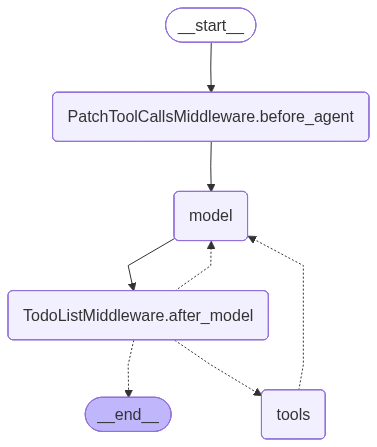

In [8]:
# Create the agent
agent = create_deep_agent(
      model=model,
      tools=tools, 
      system_prompt=INSTRUCTIONS,
      subagents=[research_sub_agent],
  )
  
# Show the agent
display(Image(agent.get_graph().draw_mermaid_png()))

In [9]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "research context engineering approaches used to build AI agents",
            }
        ],
    }, 
)
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ research context engineering approaches used to build AI agents                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Save user research request to /research_request.md",                                          │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Delegate research to a sub-agent to gather sources and summarize context engineering          │
│ approaches for AI agents",                                                                                      │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize findings, consolidate citations, and draft report",                                │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Write /final_report.md and verify it addresses the request with citations",                   │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_m6tLdR8my9Pm93KrwAQArh9p                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Save user research request to /research_request.md', 'status':               │
│ 'in_progress'}, {'content': 'Delegate research to a sub-agent to gather sources and summarize context           │
│ engineering approaches for AI agents', 'status': 'pending'}, {'content': 'Synthesize findings, consolidate      │
│ citations, and draft report', 'status': 'pending'}, {'content': 'Write /final_report.md and verify it addresses │
│ the request with citations', 'status': 'pending'}]                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "/research_request.md",                                                                          │
│   "content": "Research context engineering approaches used to build AI agents.\n\nFocus:\n- How agent builders  │
│ structure and manage context (prompts/system instructions, tool schemas, memory, retrieval, state,              │
│ scratchpads)\n- Common patterns (ReAct, planner-executor, function/tool calling, reflection, self-critique,     │
│ multi-agent)\n- Techniques for context selection/compression (summarization, chunking, relevance scoring)\n-    │
│ Framework-specific practices (LangChain/LangGraph, OpenAI Assistants/Responses, Anthropic tool use, Microsoft   │
│ Autogen, LlamaIndex)\n- Practical guidance, tradeoffs, and pitfalls\n- Provide citations to primary             │
│ docs/blogs/papers\n"                                                                                            │
│ }                                                                                                               │
│    ID: call_QAYlpHidqjFBXjZqBkI7pttJ                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file /research_request.md                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│      1  Research context engineering approaches used to build AI agents.                                        │
│      2                                                                                                          │
│      3  Focus:                                                                                                  │
│      4  - How agent builders structure and manage context (prompts/system instructions, tool schemas, memory,   │
│ retrieval, state, scratchpads)                                                                                  │
│      5  - Common patterns (ReAct, planner-executor, function/tool calling, reflection, self-critique,           │
│ multi-agent)                                                                                                    │
│      6  - Techniques for context selection/compression (summarization, chunking, relevance scoring)             │
│      7  - Framework-specific practices (LangChain/LangGraph, OpenAI Assistants/Responses, Anthropic tool use,   │
│ Microsoft Autogen, LlamaIndex)                                                                                  │
│      8  - Practical guidance, tradeoffs, and pitfalls                                                           │
│      9  - Provide citations to primary docs/blogs/papers                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│      1  ## Overview of context engineering for AI agents                                                        │
│      2                                                                                                          │
│      3  Context engineering for AI agents is the discipline of constructing, updating, and constraining what an │
│ LLM sees in its context window at every step of an agent run—combining stable instructions, tool affordances,   │
│ retrieved knowledge, and accumulated intermediate results so the model can reliably decide what to do next. A   │
│ common framing is that it is “the art and science of filling the context window with just the right information │
│ at each step of an agent’s trajectory,” and that effective approaches can be grouped into four broad            │
│ strategies: **write**, **select**, **compress**, and **isolate** [1]. This framing emphasizes that “prompting”  │
│ is only one part of agent reliability; the larger challenge is keeping multi-step tool-using trajectories       │
│ coherent under token limits while resisting distraction and prompt injection.                                   │
│      4                                                                                                          │
│      5  Long and messy contexts degrade agent performance in recognizable ways (e.g., irrelevant or malicious   │
│ content “poisoning” the context, the model being distracted by stale details, confusion from conflicting        │
│ instructions, or clashes between different retrieved snippets) [1]. As a result, context engineering approaches │
│ are typically designed around (a) explicit structure, (b) aggressive relevance filtering, and (c) careful       │
│ management of tool inputs/outputs.                                                                              │
│      6                                                                                                          │
│      7  ## Key concept 1: Instruction and prompt structuring (static vs dynamic context)                        │
│      8                                                                                                          │
│      9  A foundational approach is to **separate stable guidance from dynamic run state**. Stable guidance      │
│ includes the agent’s role, high-level objectives, tool-use policies, formatting requirements, and safety        │
│ constraints. Dynamic context includes the specific user task, current plan/subgoal, recent observations,        │
│ retrieved memories/documents, and tool outputs.                                                                 │
│     10                                                                                                          │
│     11  In practical agent builds, this separation is implemented by:                                           │
│     12                                                                                                          │
│     13  1. **Layering instructions by privilege and stability.** Put non-negotiable rules and tool-use policy   │
│ in the highest-priority instruction layer available, while keeping per-task content and volatile artifacts      │
│ (like retrieved documents) clearly labeled and lower priority.                                                  │
│     14                                                                                                          │
│     15  2. **Encoding “procedural memory” as reusable prompts.** LangGraph’s memory taxonomy identifies         │
│ **procedural memory** as durable instructions (system prompts, rules, “how to act”) that persist across runs    │
│ and shape behavior [2]. Treating these as explicit, versioned artifacts (rather than ad-hoc strings) makes      │
│ changes auditable and testable.                        

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Save user research request to /research_request.md",                                          │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Delegate research to a sub-agent to gather sources and summarize context engineering          │
│ approaches for AI agents",                                                                                      │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize findings, consolidate citations, and draft report",                                │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Write /final_report.md and verify it addresses the request with citations",                   │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_slXOFV9fWrlEKxZ4qfUDKi09                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Save user research request to /research_request.md', 'status': 'completed'}, │
│ {'content': 'Delegate research to a sub-agent to gather sources and summarize context engineering approaches    │
│ for AI agents', 'status': 'completed'}, {'content': 'Synthesize findings, consolidate citations, and draft      │
│ report', 'status': 'completed'}, {'content': 'Write /final_report.md and verify it addresses the request with   │
│ citations', 'status': 'completed'}]                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Completed the research report and saved it to:                                                                  │
│                                                                                                                 │
│ - `/final_report.md`                                                                                            │
│                                                                                                                 │
│ It covers:                                                                                                      │
│ - Core definition and taxonomy (write/select/compress/isolate)                                                  │
│ - Instruction/prompt structuring patterns                                                                       │
│ - Tool/function-calling schema and tool-output shaping                                                          │
│ - Memory + retrieval (short-term/long-term; semantic/episodic/procedural)                                       │
│ - Agent patterns (ReAct, Reflexion, Tree-of-Thought, multi-agent isolation)                                     │
│ - Context compression/selection techniques and practical pitfalls/tradeoffs                                     │
│ - Framework-specific practices with citations (LangChain/LangGraph, LlamaIndex, Anthropic tools, Microsoft      │
│ Agent Framework)                                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯